In [1]:
import numpy as np
from scipy.spatial.transform import Rotation
import mediapy

from motrixsim import SceneData, load_model, step
from gaussian_renderer import GSRendererMotrixSim
from gs_playground import ROOT_PATH

mjcf_path = ROOT_PATH / "models" / "robots" / "manipulation" / "franka_emika_panda_robotiq" / "xmls" / "table30_00_simple_room.xml"

_ASSETS_FRANKA_DIR = ROOT_PATH / "models" / "robots" / "manipulation" / "franka_emika_panda_robotiq"

gaussians = {
    "link1" : (_ASSETS_FRANKA_DIR / "3dgs" / "franka" / "link1.ply").as_posix(),
    "link2" : (_ASSETS_FRANKA_DIR / "3dgs" / "franka" / "link2.ply").as_posix(),
    "link3" : (_ASSETS_FRANKA_DIR / "3dgs" / "franka" / "link3.ply").as_posix(),
    "link4" : (_ASSETS_FRANKA_DIR / "3dgs" / "franka" / "link4.ply").as_posix(),
    "link5" : (_ASSETS_FRANKA_DIR / "3dgs" / "franka" / "link5.ply").as_posix(),
    "link6" : (_ASSETS_FRANKA_DIR / "3dgs" / "franka" / "link6.ply").as_posix(),
    "link7" : (_ASSETS_FRANKA_DIR / "3dgs" / "franka" / "link7.ply").as_posix(),

    "robotiq_base"      : (_ASSETS_FRANKA_DIR / "3dgs" / "robotiq" / "robotiq_base.ply").as_posix(),
    "left_driver"       : (_ASSETS_FRANKA_DIR / "3dgs" / "robotiq" / "left_driver.ply").as_posix(),
    "left_coupler"      : (_ASSETS_FRANKA_DIR / "3dgs" / "robotiq" / "left_coupler.ply").as_posix(),
    "left_spring_link"  : (_ASSETS_FRANKA_DIR / "3dgs" / "robotiq" / "left_spring_link.ply").as_posix(),
    "left_follower"     : (_ASSETS_FRANKA_DIR / "3dgs" / "robotiq" / "left_follower.ply").as_posix(),

    "right_driver"      : (_ASSETS_FRANKA_DIR / "3dgs" / "robotiq" / "right_driver.ply").as_posix(),
    "right_coupler"     : (_ASSETS_FRANKA_DIR / "3dgs" / "robotiq" / "right_coupler.ply").as_posix(),
    "right_spring_link" : (_ASSETS_FRANKA_DIR / "3dgs" / "robotiq" / "right_spring_link.ply").as_posix(),
    "right_follower"    : (_ASSETS_FRANKA_DIR / "3dgs" / "robotiq" / "right_follower.ply").as_posix(),

}
background = (_ASSETS_FRANKA_DIR / "3dgs" / "simple_room.ply").as_posix()

Motphys profiler initialized: disabled


## Single Env

""

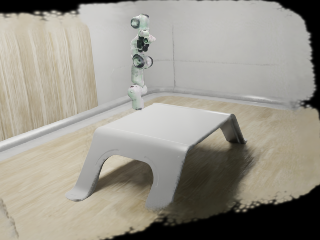

In [2]:
# Load the scene model
mx_model = load_model(mjcf_path.as_posix())
mx_data = SceneData(mx_model)

# Initialize the simulation
mx_model.keyframes[0].apply(mx_data)
step(mx_model, mx_data)

gaussians.update({"background": background})
gsmx_renderer = GSRendererMotrixSim(gaussians, mx_model)
gaussians.pop("background")
gsmx_renderer.update_gaussians(mx_data)
results = gsmx_renderer.render(mx_model, mx_data, list(range(len(mx_model.cameras))), 320, 240)
for k, (rgb, depth) in results.items():
    rgb_np = rgb.cpu().numpy()
    mediapy.show_image(rgb_np)

## Batch Env

In [3]:
import time
from contextlib import contextmanager

num_env = 2048

@contextmanager
def step_timer(name, rollout=False):
    t0 = time.perf_counter()
    yield
    t1 = time.perf_counter()
    if not rollout:
        print(f"[{name}] {(t1 - t0) * 1000:.3f} ms")
    else:
        print(f"[{name}] {(t1 - t0) * 1000:.3f} ms, total fps={num_env / (t1 - t0):.2f}")

from gaussian_renderer import BatchSplatConfig, MtxBatchSplatRenderer


# Load the scene model
mx_model = load_model(mjcf_path.as_posix())
mx_data = SceneData(mx_model, batch=(num_env, ))

# Initialize the simulation
mx_model.keyframes[0].apply(mx_data)
with step_timer("Step 1: Physics Rollout + Sensor Compute", True):
    step(mx_model, mx_data)

cid = 0
cam = mx_model.cameras[cid]
cam_pose = cam.get_pose(mx_data)
link_poses = mx_model.get_link_poses(mx_data)

# H, W = 240, 320
# H, W = 1,1
H, W = 128,128
# H, W = 256,256
# H, W = 480, 480
# H, W = 720, 1280
cfg = BatchSplatConfig(body_gaussians=gaussians, background_ply=None, minibatch=num_env)
renderer = MtxBatchSplatRenderer(cfg, mx_model)

# --- Step 2: batch_update_gaussians ---
body_pos = link_poses[...,:3]  # (Nenv, Nbody, 3)
body_quat = link_poses[...,3:]  # (Nenv, Nbody, 4) xyzw
assert np.linalg.norm(body_quat, axis=-1).min() > 1 - 1e-6 and np.linalg.norm(body_quat, axis=-1).max() < 1 + 1e-6, "Quaternion norm is too small."
print(body_pos.shape, body_quat.shape)

(256, 19, 3) (256, 19, 4)


RGB: torch.Size([256, 1, 128, 128, 3]) Depth: torch.Size([256, 1, 128, 128, 1])
4 (16, 128, 128, 3)


""

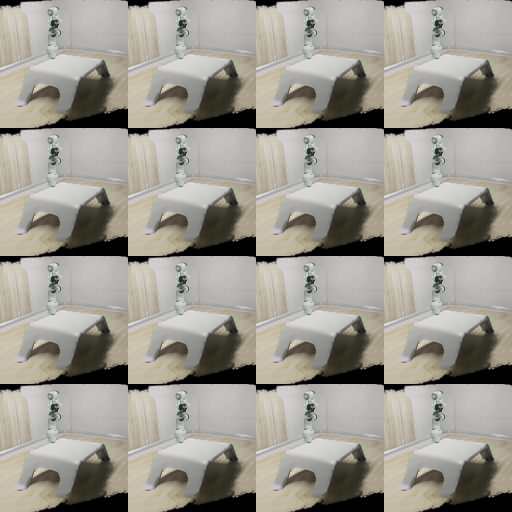

In [4]:
H, W = 240, 320
cfg = BatchSplatConfig(body_gaussians=gaussians, background_ply=None, minibatch=512)
renderer = MtxBatchSplatRenderer(cfg, mx_model)

gsb = renderer.batch_update_gaussians(body_pos, body_quat)

# --- Step 3: batch_env_render ---
cam_pos_lst = []
cam_xmat_lst = []
fovy_lst = []
for cid in range(len(mx_model.cameras)):
    cam = mx_model.cameras[cid]
    cam_pose = cam.get_pose(mx_data)
    cam_pos_lst.append(cam_pose[...,:3])
    cam_xmat_lst.append(Rotation.from_quat(cam_pose[... ,3:7]).as_matrix().reshape(num_env, 9))
    fovy_lst.append(mx_model.cameras[cid].fovy)
cam_pos = np.array(cam_pos_lst).transpose(1, 0, 2)
cam_xmat = np.array(cam_xmat_lst).transpose(1, 0, 2)
fovy = np.array(fovy_lst)
fovy = np.tile(fovy, (num_env, 1))

# 这个只在最开始运行一次即可，获取背景图像
bg_renderer = MtxBatchSplatRenderer(BatchSplatConfig(body_gaussians=dict(), background_ply=background, minibatch=num_env), mx_model)
bg_gsb = bg_renderer.batch_update_gaussians(body_pos, body_quat)
bg_imgs, _ = bg_renderer.batch_env_render(bg_gsb, cam_pos, cam_xmat, H, W, fovy)

# --- Step 4: batch_env_render ---
rgb, depth = renderer.batch_env_render(gsb, cam_pos, cam_xmat, H, W, fovy, bg_imgs)

print('RGB:', rgb.shape, 'Depth:', depth.shape)
def tile(img, d):
    assert img.shape[0] == d*d
    print(d, img.shape)
    img = img.reshape((d,d)+img.shape[1:])
    return np.concat(np.concat(img, axis=1), axis=1)
mediapy.show_image(tile(rgb[:16,0,...].cpu().numpy(), 4), width=1080)

In [5]:
import torch

torch.cuda.synchronize()
start_event = torch.cuda.Event(enable_timing=True)
end_event = torch.cuda.Event(enable_timing=True)
elapsed_ms = []
for _ in range(10):
    start_event.record()
    # renderer.batch_env_render(gsb, cam_pos, cam_xmat, H, W, fovy)
    renderer.batch_env_render(gsb, cam_pos, cam_xmat, H, W, fovy, bg_imgs)
    end_event.record()
    torch.cuda.synchronize()
    elapsed_ms.append(start_event.elapsed_time(end_event))
avg_ms = float(np.mean(elapsed_ms))
print(f"Average render time over 10 runs: {avg_ms:.3f} ms")
# images per second
ips = num_env * len(mx_model.cameras) / (avg_ms / 1000.0)
print(f"Throughput: {ips:.1f} images/s")

Average render time over 10 runs: 67.559 ms
Throughput: 3789.3 images/s
